# The Bates Stochastic Volatility Jump Model

## Introduction

The **Bates model** (Bates, 1996) is an extension of the Heston stochastic volatility model that incorporates **jump diffusion** to capture sudden, discontinuous movements in asset prices. It combines:

1. **Heston's stochastic volatility** (1993) - for modeling volatility clustering and mean reversion
2. **Merton's jump diffusion** (1976) - for modeling sudden price jumps (crashes or rallies)

This makes the Bates model particularly useful for:
- Pricing options during periods of market stress
- Capturing the **volatility smile/skew** more accurately than Heston alone
- Modeling **fat tails** (leptokurtosis) observed in real market returns
- Better pricing of **short-dated** and **out-of-the-money** options

## Mathematical Formulation

The Bates model is defined by two coupled stochastic differential equations (SDEs) under the risk-neutral measure $\mathbb{Q}$:

### Asset Price Process (with Jumps):
$dS_t = (r - q - \lambda_p \bar{k})S_t dt + \sqrt{v_t} S_t dW_t^S + (J-1)S_{t^-} dN_t$

### Variance Process (CIR/Heston):
$dv_t = \kappa(\theta - v_t)dt + \sigma_v\sqrt{v_t}dW_t^v$

### Correlation Structure:
$\mathbb{E}[dW_t^S \cdot dW_t^v] = \rho \, dt$

### Jump Component:
- $N_t$ is a **Poisson process** with intensity $\lambda_p$ (average number of jumps per year)
- $J$ is the **random jump multiplier** where $\ln(J) \sim \mathcal{N}(\mu_J - \frac{\delta^2}{2}, \delta^2)$
- $\bar{k} = \mathbb{E}[J-1] = e^{\mu_J} - 1$ is the **expected relative jump size**

## Parameter Definitions

| Parameter | Symbol | Description | Typical Range |
|-----------|--------|-------------|---------------|
| Initial variance | $v_0$ | Starting variance level | 0.01 - 0.2 |
| Long-term variance | $\theta$ | Mean reversion level for variance | 0.01 - 0.2 |
| Mean reversion speed | $\kappa$ | Rate of variance mean reversion | 0.5 - 5.0 |
| Volatility of volatility | $\sigma_v$ | Vol of vol (controls variance dynamics) | 0.1 - 1.0 |
| Correlation | $\rho$ | Correlation between asset and variance | -0.9 to 0 |
| Jump intensity | $\lambda_p$ | Average number of jumps per year | 0.01 - 1.0 |
| Mean jump size | $\mu_J$ | Expected log jump size | -0.2 to 0.2 |
| Jump volatility | $\delta$ | Std dev of log jump size | 0.01 - 0.3 |

## Key Properties

### 1. Feller Condition (Variance Positivity):
$2\kappa\theta > \sigma_v^2$

This ensures the variance process remains strictly positive.

### 2. Jump Compensation:
The term $-\lambda_p \bar{k}$ in the drift compensates for the expected jump to ensure the discounted asset price is a martingale under $\mathbb{Q}$.

### 3. Decomposition:
The Bates model can be decomposed as:
- **Continuous component**: Heston stochastic volatility
- **Discrete component**: Merton-style jumps

This decomposition is crucial for the characteristic function approach.

## Discretization for Monte Carlo Simulation

Using the Euler-Maruyama scheme, we discretize the SDEs:

### Variance Discretization (Full Truncation Scheme):
$v_{t+\Delta t} = v_t + \kappa(\theta - v_t^+)\Delta t + \sigma_v\sqrt{v_t^+}\sqrt{\Delta t}Z_v$

where $v_t^+ = \max(v_t, 0)$ ensures non-negativity.

### Asset Price Discretization (Log-Price):
For numerical stability, we work with log-prices $X_t = \ln(S_t)$:

$X_{t+\Delta t} = X_t + (r - q - \lambda_p \bar{k} - \frac{v_t}{2})\Delta t + \sqrt{v_t^+}\sqrt{\Delta t}Z_S + \sum_{i=1}^{N_{\Delta t}} \ln(J_i)$

### Generating Correlated Brownian Motions:
$Z_S \sim \mathcal{N}(0,1)$

$Z_v = \rho Z_S + \sqrt{1-\rho^2} Z_{\perp}$ where $Z_{\perp} \sim \mathcal{N}(0,1)$

### Generating Jumps:
1. Sample number of jumps: $N_{\Delta t} \sim \text{Poisson}(\lambda_p \Delta t)$
2. Sample jump sizes: $\ln(J_i) \sim \mathcal{N}(\mu_J - \frac{\delta^2}{2}, \delta^2)$

### Terminal Stock Price:
$S_T = e^{X_T}$

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import minimize, brentq
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Model 1: Bates Model using Monte Carlo Simulation

This implementation uses Monte Carlo simulation to price options under the Bates stochastic volatility jump model.

### Key Implementation Details:
1. **Full truncation scheme** for variance to ensure positivity
2. **Log-price formulation** for numerical stability
3. **Poisson-distributed jumps** with log-normal jump sizes
4. **Correlated Brownian motions** via Cholesky decomposition

In [2]:
class BatesUsingMCS:
    """
    Bates Stochastic Volatility Jump Model using Monte Carlo Simulation
    
    The Bates model extends Heston by adding Merton-style jumps:
    - Stochastic volatility (CIR process)
    - Poisson-distributed jumps with log-normal sizes
    
    Jump parameterization: ln(J) ~ N(mu_J, delta^2)
    This means E[J] = exp(mu_J + delta^2/2)
    """
    
    def __init__(self, S0, v0, rho, kappa, theta, sigma_v, T, N, M, r, K, 
                 lambda_p, mu_J, delta, q=0):
        """
        Initialize Bates Model parameters
        
        Parameters:
        -----------
        S0 : float - Initial stock price
        v0 : float - Initial variance
        rho : float - Correlation between asset and variance (-1 to 1)
        kappa : float - Mean reversion speed of variance
        theta : float - Long-term variance level
        sigma_v : float - Volatility of volatility
        T : float - Time to maturity (years)
        N : int - Number of time steps
        M : int - Number of Monte Carlo paths
        r : float - Risk-free rate
        K : float - Strike price
        lambda_p : float - Jump intensity (jumps per year)
        mu_J : float - Mean of log jump size (ln(J) ~ N(mu_J, delta^2))
        delta : float - Std dev of log jump size
        q : float - Dividend yield (default 0)
        """
        self.S0 = S0
        self.v0 = v0
        self.rho = rho
        self.kappa = kappa
        self.theta = theta
        self.sigma_v = sigma_v
        self.T = T
        self.N = N
        self.M = M
        self.r = r
        self.K = K
        self.lambda_p = lambda_p
        self.mu_J = mu_J
        self.delta = delta
        self.q = q
        self.dt = T / N
        
        # Expected relative jump size: E[J] - 1 = exp(mu_J + delta^2/2) - 1
        # Since ln(J) ~ N(mu_J, delta^2), we have E[J] = exp(mu_J + delta^2/2)
        self.k_bar = np.exp(self.mu_J + 0.5 * self.delta**2) - 1
        
        # Check Feller condition
        if 2 * kappa * theta <= sigma_v**2:
            print(f"Warning: Feller condition violated (2*kappa*theta = {2*kappa*theta:.4f} <= sigma_v^2 = {sigma_v**2:.4f})")
            print("Variance may become negative. Using full truncation scheme.")
    
    def simulate_paths(self):
        """
        Simulate M paths of stock prices and variances using Euler-Maruyama scheme.
        Returns terminal stock prices and full paths for visualization.
        """
        # Initialize arrays
        S = np.zeros((self.M, self.N + 1))
        v = np.zeros((self.M, self.N + 1))
        S[:, 0] = self.S0
        v[:, 0] = self.v0
        
        # Pre-compute constants
        sqrt_dt = np.sqrt(self.dt)
        drift_adj = self.r - self.q - self.lambda_p * self.k_bar
        
        for i in range(1, self.N + 1):
            # Generate correlated Brownian increments
            Z1 = np.random.standard_normal(self.M)
            Z2 = np.random.standard_normal(self.M)
            Z_S = Z1
            Z_v = self.rho * Z1 + np.sqrt(1 - self.rho**2) * Z2
            
            # Variance update (Full truncation scheme)
            v_pos = np.maximum(v[:, i-1], 0)
            v[:, i] = v[:, i-1] + self.kappa * (self.theta - v_pos) * self.dt + \
                      self.sigma_v * np.sqrt(v_pos) * sqrt_dt * Z_v
            v[:, i] = np.maximum(v[:, i], 0)  # Ensure non-negativity
            
            # Generate jumps
            # Number of jumps in this time step (Poisson distributed)
            N_jumps = np.random.poisson(self.lambda_p * self.dt, self.M)
            
            # Total jump size for this time step
            # For each path, sum the log-normal jumps
            # ln(J) ~ N(mu_J, delta^2)
            jump_component = np.zeros(self.M)
            for j in range(self.M):
                if N_jumps[j] > 0:
                    log_jumps = np.random.normal(self.mu_J, self.delta, N_jumps[j])
                    jump_component[j] = np.sum(log_jumps)
            
            # Stock price update using log formulation
            log_S = np.log(S[:, i-1]) + (drift_adj - 0.5 * v_pos) * self.dt + \
                    np.sqrt(v_pos) * sqrt_dt * Z_S + jump_component
            S[:, i] = np.exp(log_S)
        
        self.S_paths = S
        self.v_paths = v
        return S[:, -1], S, v
    
    def simulate_paths_vectorized(self):
        """
        Faster vectorized simulation using compound Poisson approximation.
        """
        S = np.zeros((self.M, self.N + 1))
        v = np.zeros((self.M, self.N + 1))
        S[:, 0] = self.S0
        v[:, 0] = self.v0
        
        sqrt_dt = np.sqrt(self.dt)
        drift_adj = self.r - self.q - self.lambda_p * self.k_bar
        
        for i in range(1, self.N + 1):
            Z1 = np.random.standard_normal(self.M)
            Z2 = np.random.standard_normal(self.M)
            Z_S = Z1
            Z_v = self.rho * Z1 + np.sqrt(1 - self.rho**2) * Z2
            
            v_pos = np.maximum(v[:, i-1], 0)
            v[:, i] = v[:, i-1] + self.kappa * (self.theta - v_pos) * self.dt + \
                      self.sigma_v * np.sqrt(v_pos) * sqrt_dt * Z_v
            v[:, i] = np.maximum(v[:, i], 0)
            
            # Vectorized jump simulation
            # Sum of N i.i.d. Normal(mu_J, delta^2) is Normal(N*mu_J, N*delta^2)
            N_jumps = np.random.poisson(self.lambda_p * self.dt, self.M)
            jump_mean = N_jumps * self.mu_J
            jump_std = np.sqrt(N_jumps) * self.delta
            jump_component = np.where(N_jumps > 0, 
                                      jump_mean + jump_std * np.random.standard_normal(self.M),
                                      0)
            
            log_S = np.log(S[:, i-1]) + (drift_adj - 0.5 * v_pos) * self.dt + \
                    np.sqrt(v_pos) * sqrt_dt * Z_S + jump_component
            S[:, i] = np.exp(log_S)
        
        self.S_paths = S
        self.v_paths = v
        return S[:, -1], S, v
    
    def price_call(self, use_vectorized=True):
        """
        Price a European call option using Monte Carlo simulation.
        
        Returns:
        --------
        price : float - Option price
        std_error : float - Standard error of the estimate
        """
        if use_vectorized:
            S_T, _, _ = self.simulate_paths_vectorized()
        else:
            S_T, _, _ = self.simulate_paths()
        
        payoffs = np.maximum(S_T - self.K, 0)
        discounted_payoffs = np.exp(-self.r * self.T) * payoffs
        
        price = np.mean(discounted_payoffs)
        std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(self.M)
        
        return price, std_error
    
    def price_put(self, use_vectorized=True):
        """
        Price a European put option using Monte Carlo simulation.
        
        Returns:
        --------
        price : float - Option price
        std_error : float - Standard error of the estimate
        """
        if use_vectorized:
            S_T, _, _ = self.simulate_paths_vectorized()
        else:
            S_T, _, _ = self.simulate_paths()
        
        payoffs = np.maximum(self.K - S_T, 0)
        discounted_payoffs = np.exp(-self.r * self.T) * payoffs
        
        price = np.mean(discounted_payoffs)
        std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(self.M)
        
        return price, std_error

In [3]:
# Example parameters (typical values for equity index options)
S0 = 100      # Initial stock price
v0 = 0.04     # Initial variance (20% volatility)
K = 100       # At-the-money strike
T = 1.0       # 1 year to maturity
r = 0.05      # Risk-free rate

# Heston parameters (stochastic volatility)
kappa = 2.0   # Mean reversion speed
theta = 0.04  # Long-term variance
sigma_v = 0.3 # Volatility of volatility
rho = -0.7    # Negative correlation (leverage effect)

# Jump parameters (Merton component)
lambda_p = 0.1  # Average 0.1 jumps per year (1 jump every 10 years)
mu_J = -0.05    # Mean log jump size (-5%, typical for crash)
delta = 0.1     # Jump size volatility

# Simulation parameters
N = 252       # Daily steps
M = 50000     # Number of paths

print("Bates Model Parameters:")
print("="*50)
print(f"Initial Price (S0): {S0}")
print(f"Strike (K): {K}")
print(f"Time to Maturity (T): {T} years")
print(f"Risk-free Rate (r): {r*100:.2f}%")
print(f"\nStochastic Volatility Parameters:")
print(f"  Initial Variance (v0): {v0} ({np.sqrt(v0)*100:.1f}% vol)")
print(f"  Long-term Variance (theta): {theta}")
print(f"  Mean Reversion (kappa): {kappa}")
print(f"  Vol of Vol (sigma_v): {sigma_v}")
print(f"  Correlation (rho): {rho}")
print(f"\nJump Parameters:")
print(f"  Jump Intensity (lambda): {lambda_p} jumps/year")
print(f"  Mean Jump Size (mu_J): {mu_J}")
print(f"  Jump Volatility (delta): {delta}")
print(f"  Expected Relative Jump E[J-1]: {np.exp(mu_J)-1:.4f}")
print(f"\nFeller Condition: 2*kappa*theta = {2*kappa*theta:.4f} vs sigma_v^2 = {sigma_v**2:.4f}")

Bates Model Parameters:
Initial Price (S0): 100
Strike (K): 100
Time to Maturity (T): 1.0 years
Risk-free Rate (r): 5.00%

Stochastic Volatility Parameters:
  Initial Variance (v0): 0.04 (20.0% vol)
  Long-term Variance (theta): 0.04
  Mean Reversion (kappa): 2.0
  Vol of Vol (sigma_v): 0.3
  Correlation (rho): -0.7

Jump Parameters:
  Jump Intensity (lambda): 0.1 jumps/year
  Mean Jump Size (mu_J): -0.05
  Jump Volatility (delta): 0.1
  Expected Relative Jump E[J-1]: -0.0488

Feller Condition: 2*kappa*theta = 0.1600 vs sigma_v^2 = 0.0900


## Parameters and Model Initialization

Setting up the Bates model with realistic market parameters.

In [4]:
# Create Bates model instance
bates_mcs = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, N, M, r, K, 
                          lambda_p, mu_J, delta)

# Price options
call_price, call_se = bates_mcs.price_call()
put_price, put_se = bates_mcs.price_put()

print("\nMonte Carlo Option Prices:")
print("="*50)
print(f"Call Price: {call_price:.4f} (+/- {1.96*call_se:.4f} at 95% CI)")
print(f"Put Price: {put_price:.4f} (+/- {1.96*put_se:.4f} at 95% CI)")

# Verify put-call parity
parity_lhs = call_price - put_price
parity_rhs = S0 * np.exp(-bates_mcs.q * T) - K * np.exp(-r * T)
print(f"\nPut-Call Parity Check:")
print(f"  C - P = {parity_lhs:.4f}")
print(f"  S*exp(-qT) - K*exp(-rT) = {parity_rhs:.4f}")
print(f"  Difference: {abs(parity_lhs - parity_rhs):.6f}")


Monte Carlo Option Prices:
Call Price: 10.3965 (+/- 0.1083 at 95% CI)
Put Price: 5.6126 (+/- 0.0881 at 95% CI)

Put-Call Parity Check:
  C - P = 4.7839
  S*exp(-qT) - K*exp(-rT) = 4.8771
  Difference: 0.093147


## Option Pricing Results

Computing call and put option prices using the Monte Carlo simulation.

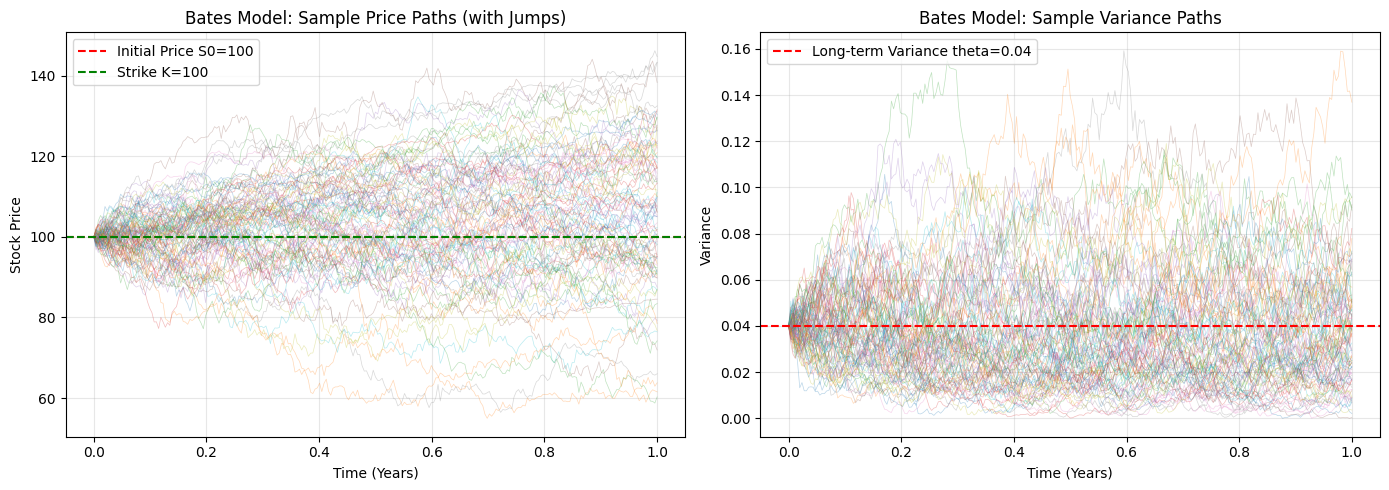

In [5]:
# Visualize sample paths
np.random.seed(42)
_, S_paths, v_paths = bates_mcs.simulate_paths_vectorized()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
time = np.linspace(0, T, N+1)

# Plot price paths (first 100)
for i in range(min(100, M)):
    ax1.plot(time, S_paths[i], alpha=0.3, linewidth=0.5)
ax1.axhline(y=S0, color='r', linestyle='--', label=f'Initial Price S0={S0}')
ax1.axhline(y=K, color='g', linestyle='--', label=f'Strike K={K}')
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('Stock Price')
ax1.set_title('Bates Model: Sample Price Paths (with Jumps)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot variance paths (first 100)
for i in range(min(100, M)):
    ax2.plot(time, v_paths[i], alpha=0.3, linewidth=0.5)
ax2.axhline(y=theta, color='r', linestyle='--', label=f'Long-term Variance theta={theta}')
ax2.set_xlabel('Time (Years)')
ax2.set_ylabel('Variance')
ax2.set_title('Bates Model: Sample Variance Paths')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Compare Bates with Heston (no jumps) using Monte Carlo
print("Comparing Bates vs Heston (No Jumps):")
print("="*60)

# Bates with jumps
bates_with_jumps = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, N, M, r, K,
                                  lambda_p=0.1, mu_J=-0.05, delta=0.1)
call_bates, se_bates = bates_with_jumps.price_call()

# Heston (Bates with no jumps: lambda=0)
heston_no_jumps = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, N, M, r, K,
                                 lambda_p=0, mu_J=0, delta=0)
call_heston, se_heston = heston_no_jumps.price_call()

print(f"Bates Call (with jumps): {call_bates:.4f} +/- {1.96*se_bates:.4f}")
print(f"Heston Call (no jumps):  {call_heston:.4f} +/- {1.96*se_heston:.4f}")
print(f"Difference: {call_bates - call_heston:.4f}")

Comparing Bates vs Heston (No Jumps):
Bates Call (with jumps): 10.6120 +/- 0.1093
Heston Call (no jumps):  10.4667 +/- 0.1082
Difference: 0.1452


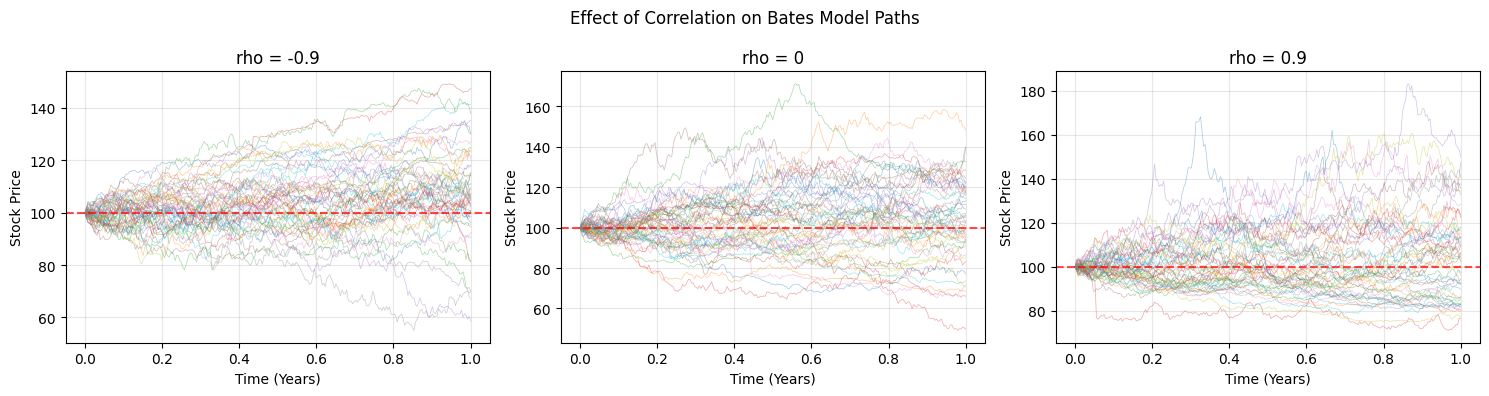

In [7]:
# Effect of correlation on price paths
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

correlations = [-0.9, 0, 0.9]
np.random.seed(42)

for idx, rho_test in enumerate(correlations):
    bates_test = BatesUsingMCS(S0, v0, rho_test, kappa, theta, sigma_v, T, N, 500, r, K,
                                lambda_p, mu_J, delta)
    _, S_test, _ = bates_test.simulate_paths_vectorized()
    
    for i in range(50):
        axes[idx].plot(np.linspace(0, T, N+1), S_test[i], alpha=0.4, linewidth=0.5)
    axes[idx].axhline(y=S0, color='r', linestyle='--', alpha=0.7)
    axes[idx].set_title(f'rho = {rho_test}')
    axes[idx].set_xlabel('Time (Years)')
    axes[idx].set_ylabel('Stock Price')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Effect of Correlation on Bates Model Paths', fontsize=12)
plt.tight_layout()
plt.show()

## Implied Volatility Smile

The Bates model captures the volatility smile better than Black-Scholes due to:
1. **Stochastic volatility** - Creates smile curvature
2. **Jumps** - Creates additional skew, especially for short maturities

Computing implied volatility smile...
K=70: Bates IV=24.60%, Heston IV=26.66%
K=72: Bates IV=23.99%, Heston IV=23.67%
K=75: Bates IV=22.13%, Heston IV=22.24%
K=78: Bates IV=21.37%, Heston IV=22.95%
K=80: Bates IV=23.01%, Heston IV=23.08%
K=82: Bates IV=24.71%, Heston IV=21.92%
K=85: Bates IV=22.61%, Heston IV=22.29%
K=88: Bates IV=21.73%, Heston IV=21.80%
K=90: Bates IV=21.13%, Heston IV=22.43%
K=92: Bates IV=21.57%, Heston IV=20.81%
K=95: Bates IV=21.32%, Heston IV=20.82%
K=98: Bates IV=20.15%, Heston IV=20.48%
K=100: Bates IV=20.30%, Heston IV=19.65%
K=102: Bates IV=19.87%, Heston IV=19.55%
K=105: Bates IV=19.26%, Heston IV=19.28%
K=108: Bates IV=18.95%, Heston IV=19.29%
K=110: Bates IV=19.18%, Heston IV=18.92%
K=112: Bates IV=18.60%, Heston IV=18.23%
K=115: Bates IV=18.14%, Heston IV=17.71%
K=118: Bates IV=17.91%, Heston IV=17.25%
K=120: Bates IV=17.33%, Heston IV=17.23%
K=122: Bates IV=16.82%, Heston IV=17.00%
K=125: Bates IV=17.32%, Heston IV=16.35%
K=128: Bates IV=16.49%, Heston 

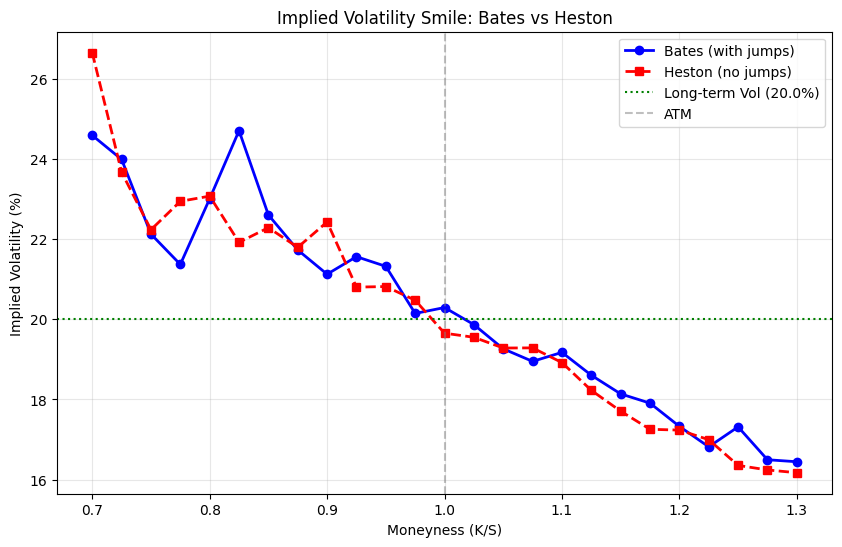

In [8]:
# Generate implied volatility smile
def black_scholes_call(S, K, T, r, sigma):
    """Black-Scholes call price"""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol_from_price(S, K, T, r, market_price, option_type='call'):
    """Extract implied volatility from option price using bisection"""
    def objective(sigma):
        if option_type == 'call':
            return black_scholes_call(S, K, T, r, sigma) - market_price
        else:
            return (black_scholes_call(S, K, T, r, sigma) - S + K*np.exp(-r*T)) - market_price
    
    try:
        return brentq(objective, 0.001, 3.0)
    except:
        return np.nan

# Calculate smile for different strikes
strikes = np.linspace(70, 130, 25)
implied_vols_bates = []
implied_vols_heston = []

print("Computing implied volatility smile...")
for K_test in strikes:
    # Bates model price
    bates_test = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, N, 10000, r, K_test,
                                lambda_p, mu_J, delta)
    price_bates, _ = bates_test.price_call()
    iv_bates = implied_vol_from_price(S0, K_test, T, r, price_bates)
    implied_vols_bates.append(iv_bates)
    
    # Heston model price (no jumps)
    heston_test = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, N, 10000, r, K_test,
                                 0, 0, 0)
    price_heston, _ = heston_test.price_call()
    iv_heston = implied_vol_from_price(S0, K_test, T, r, price_heston)
    implied_vols_heston.append(iv_heston)
    
    print(f"K={K_test:.0f}: Bates IV={iv_bates*100:.2f}%, Heston IV={iv_heston*100:.2f}%")

# Plot smile
plt.figure(figsize=(10, 6))
plt.plot(strikes/S0, np.array(implied_vols_bates)*100, 'b-o', label='Bates (with jumps)', linewidth=2)
plt.plot(strikes/S0, np.array(implied_vols_heston)*100, 'r--s', label='Heston (no jumps)', linewidth=2)
plt.axhline(y=np.sqrt(theta)*100, color='g', linestyle=':', label=f'Long-term Vol ({np.sqrt(theta)*100:.1f}%)')
plt.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility (%)')
plt.title('Implied Volatility Smile: Bates vs Heston')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Bates Model: Characteristic Function Approach

## Semi-Analytical Pricing via Fourier Transform

The key insight is that the **characteristic function** of the Bates model can be decomposed:

$\varphi_{\text{Bates}}(u) = \varphi_{\text{Heston}}(u) \cdot \varphi_{\text{Jump}}(u)$

Since jumps are independent of the diffusion component, we can multiply the characteristic functions.

## Heston Characteristic Function

The Heston component (from Heston 1993):

$\varphi_{\text{Heston}}(u; v_0, \tau) = \exp\left(C(\tau; u) + D(\tau; u) v_0 + iu \ln S_0\right)$

where:

$C(\tau; u) = r u i \tau + \frac{\kappa \theta}{\sigma_v^2} \left[(\kappa - \rho \sigma_v u i + d)\tau - 2\ln\left(\frac{1 - g e^{d\tau}}{1 - g}\right)\right]$

$D(\tau; u) = \frac{\kappa - \rho \sigma_v u i + d}{\sigma_v^2} \cdot \frac{1 - e^{d\tau}}{1 - g e^{d\tau}}$

$d = \sqrt{(\rho \sigma_v u i - \kappa)^2 + \sigma_v^2(u i + u^2)}$

$g = \frac{\kappa - \rho \sigma_v u i + d}{\kappa - \rho \sigma_v u i - d}$

## Jump Characteristic Function (Merton Component)

For log-normally distributed jumps:

$\varphi_{\text{Jump}}(u) = \exp\left(\lambda_p \tau \left[e^{u i \mu_J - \frac{u^2 \delta^2}{2} + \frac{u i (u i - 1) \delta^2}{2}} - 1\right] - \lambda_p \bar{k} u i \tau\right)$

Simplifying:

$\varphi_{\text{Jump}}(u) = \exp\left(\lambda_p \tau \left[(1 + \bar{k})^{u i} e^{\frac{\delta^2}{2} u i (u i - 1)} - 1 - \bar{k} u i\right]\right)$

where $\bar{k} = e^{\mu_J} - 1$.

## Option Pricing Formula

Using Carr-Madan (1999) or the original Heston approach:

$C(S_0, K, \tau) = S_0 P_1 - K e^{-r\tau} P_2$

where:

$P_j = \frac{1}{2} + \frac{1}{\pi} \int_0^{\infty} \text{Re}\left[\frac{e^{-iu \ln K} \varphi_j(u)}{iu}\right] du$

In [9]:
class BatesModel:
    """
    Bates Stochastic Volatility Jump Model using Characteristic Function
    
    Combines Heston characteristic function with Merton jump component
    for semi-analytical European option pricing via Fourier inversion.
    
    Jump parameterization: ln(J) ~ N(mu_J, delta^2)
    This means E[J] = exp(mu_J + delta^2/2)
    """
    
    def __init__(self, S0, K, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, tau, r, q=0):
        """
        Initialize Bates Model
        
        Parameters:
        -----------
        S0 : float - Initial stock price
        K : float - Strike price
        v0 : float - Initial variance
        kappa : float - Mean reversion speed
        theta : float - Long-term variance
        sigma_v : float - Volatility of volatility
        rho : float - Correlation
        lambda_p : float - Jump intensity
        mu_J : float - Mean log jump size (ln(J) ~ N(mu_J, delta^2))
        delta : float - Jump volatility (std dev of log jump)
        tau : float - Time to maturity
        r : float - Risk-free rate
        q : float - Dividend yield
        """
        self.S0 = S0
        self.K = K
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.sigma_v = sigma_v
        self.rho = rho
        self.lambda_p = lambda_p
        self.mu_J = mu_J
        self.delta = delta
        self.tau = tau
        self.r = r
        self.q = q
        
        # Expected relative jump size: E[J] - 1 = exp(mu_J + delta^2/2) - 1
        self.k_bar = np.exp(mu_J + 0.5 * delta**2) - 1
    
    def heston_characteristic_function(self, phi):
        """
        Heston characteristic function (continuous component)
        Using 'Little Heston Trap' formulation for numerical stability.
        """
        sigma = self.sigma_v
        kappa = self.kappa
        theta = self.theta
        rho = self.rho
        v0 = self.v0
        tau = self.tau
        r = self.r
        q = self.q
        
        i = 1j
        
        # d parameter
        d = np.sqrt((rho * sigma * phi * i - kappa)**2 + sigma**2 * (phi * i + phi**2))
        
        # g parameter (Little Heston Trap formulation for stability)
        g = (kappa - rho * sigma * phi * i - d) / (kappa - rho * sigma * phi * i + d)
        
        # Avoid numerical issues when g is close to 1
        exp_d_tau = np.exp(-d * tau)
        
        # C and D functions
        C = (r - q) * phi * i * tau + \
            (kappa * theta / sigma**2) * \
            ((kappa - rho * sigma * phi * i - d) * tau - 2 * np.log((1 - g * exp_d_tau) / (1 - g)))
        
        D = ((kappa - rho * sigma * phi * i - d) / sigma**2) * \
            ((1 - exp_d_tau) / (1 - g * exp_d_tau))
        
        return np.exp(C + D * v0 + i * phi * np.log(self.S0))
    
    def jump_characteristic_function(self, phi):
        """
        Jump (Merton) characteristic function component.
        
        For log-normally distributed jumps where ln(J) ~ N(mu_J, delta^2):
        - E[J] = exp(mu_J + delta^2/2)
        - E[J^(iu)] = exp(iu*mu_J - 0.5*u^2*delta^2)
        
        The characteristic function of the compound Poisson jump process is:
        phi_jump(u) = exp(lambda * tau * (E[J^(iu)] - 1 - iu * k_bar))
        
        where k_bar = E[J] - 1 = exp(mu_J + delta^2/2) - 1
        """
        i = 1j
        tau = self.tau
        lambda_p = self.lambda_p
        mu_J = self.mu_J
        delta = self.delta
        k_bar = self.k_bar
        
        # E[J^(iu)] for ln(J) ~ N(mu_J, delta^2)
        # This is the moment generating function of Normal evaluated at iu
        # E[exp(iu*X)] where X ~ N(mu, sigma^2) = exp(iu*mu - 0.5*u^2*sigma^2)
        E_J_iu = np.exp(i * phi * mu_J - 0.5 * phi**2 * delta**2)
        
        # Jump characteristic function with drift compensation
        exponent = lambda_p * tau * (E_J_iu - 1 - i * phi * k_bar)
        
        return np.exp(exponent)
    
    def bates_characteristic_function(self, phi):
        """
        Full Bates characteristic function = Heston * Jump
        Since jumps are independent of diffusion, CFs multiply.
        """
        return self.heston_characteristic_function(phi) * self.jump_characteristic_function(phi)
    
    def integrand_P1(self, phi):
        """Integrand for probability P1 (delta-like probability)"""
        i = 1j
        cf = self.bates_characteristic_function(phi - i)  # Shift for P1
        integrand = np.real(np.exp(-i * phi * np.log(self.K)) * cf / (i * phi * self.S0 * np.exp((self.r - self.q) * self.tau)))
        return integrand
    
    def integrand_P2(self, phi):
        """Integrand for probability P2 (exercise probability)"""
        i = 1j
        cf = self.bates_characteristic_function(phi)
        integrand = np.real(np.exp(-i * phi * np.log(self.K)) * cf / (i * phi))
        return integrand
    
    def bates_price(self, option_type='call'):
        """
        Calculate European option price using Fourier inversion.
        
        Parameters:
        -----------
        option_type : str - 'call' or 'put'
        
        Returns:
        --------
        price : float - Option price
        """
        limit = 100  # Integration upper limit
        
        # P1 integral
        integral_P1, _ = quad(self.integrand_P1, 1e-10, limit, limit=200)
        P1 = 0.5 + (1/np.pi) * integral_P1
        
        # P2 integral
        integral_P2, _ = quad(self.integrand_P2, 1e-10, limit, limit=200)
        P2 = 0.5 + (1/np.pi) * integral_P2
        
        # Call price
        call_price = self.S0 * np.exp(-self.q * self.tau) * P1 - \
                     self.K * np.exp(-self.r * self.tau) * P2
        
        if option_type.lower() == 'call':
            return max(call_price, 0)
        else:
            # Put via put-call parity
            put_price = call_price - self.S0 * np.exp(-self.q * self.tau) + \
                        self.K * np.exp(-self.r * self.tau)
            return max(put_price, 0)

In [10]:
# Test the characteristic function approach
S0 = 100.0
K = 100.0
v0 = 0.04
kappa = 2.0
theta = 0.04
sigma_v = 0.3
rho = -0.7
lambda_p = 0.1
mu_J = -0.05
delta = 0.1
tau = 1.0
r = 0.05

# Create model instance
bates_cf = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, tau, r)

# Calculate prices
call_cf = bates_cf.bates_price('call')
put_cf = bates_cf.bates_price('put')

print("Bates Model - Characteristic Function Approach:")
print("="*50)
print(f"Call Price: {call_cf:.4f}")
print(f"Put Price: {put_cf:.4f}")

# Compare with Monte Carlo
bates_mc = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, tau, 252, 100000, r, K,
                          lambda_p, mu_J, delta)
call_mc, call_se = bates_mc.price_call()
put_mc, put_se = bates_mc.price_put()

print(f"\nMonte Carlo Comparison (100k paths):")
print(f"Call Price: {call_mc:.4f} +/- {1.96*call_se:.4f}")
print(f"Put Price: {put_mc:.4f} +/- {1.96*put_se:.4f}")
print(f"\nDifference (CF - MC):")
print(f"Call: {call_cf - call_mc:.4f}")
print(f"Put: {put_cf - put_mc:.4f}")

Bates Model - Characteristic Function Approach:
Call Price: 10.5046
Put Price: 5.6276

Monte Carlo Comparison (100k paths):
Call Price: 10.5024 +/- 0.0773
Put Price: 5.6818 +/- 0.0629

Difference (CF - MC):
Call: 0.0023
Put: -0.0542


In [11]:
# Compare Bates CF vs Heston CF (testing jump component)
print("Bates vs Heston (Characteristic Function):")
print("="*50)

# Bates with jumps
bates_cf = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, 0.1, -0.05, 0.1, tau, r)
call_bates_cf = bates_cf.bates_price('call')

# Heston (no jumps - lambda=0)
heston_cf = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, 0, 0, 0, tau, r)
call_heston_cf = heston_cf.bates_price('call')

print(f"Bates Call (lambda=0.1): {call_bates_cf:.4f}")
print(f"Heston Call (lambda=0): {call_heston_cf:.4f}")
print(f"Jump Impact: {call_bates_cf - call_heston_cf:.4f}")

Bates vs Heston (Characteristic Function):
Bates Call (lambda=0.1): 10.5046
Heston Call (lambda=0): 10.3942
Jump Impact: 0.1104


In [12]:
# Annualized volatility for NIFTY (similar to other notebooks)
annual_volatility = 14.32  # From previous analysis

In [13]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime as dt
import time

def fetch_nse_data(symbol='NIFTY'):
    """
    Fetch option chain data from NSE India
    Updated to work with NSE's current API format (2024-2025)
    """
    url = f"https://www.nseindia.com/api/option-chain-indices?symbol={symbol}"
    
    # Updated headers - don't manually set Accept-Encoding
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json,text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": "https://www.nseindia.com/option-chain",
        "Connection": "keep-alive"
    }
    
    try:
        session = requests.Session()
        # First visit to set cookies
        response = session.get("https://www.nseindia.com", headers=headers, timeout=10)
        print(f"Initial request status: {response.status_code}")
        
        # Increased delay to allow cookies to settle
        time.sleep(3)
        
        # Fetch option chain data
        response = session.get(url, headers=headers, timeout=10)
        print(f"API request status: {response.status_code}")
        
        # Check if response has content
        if not response.text or response.text.strip() == "":
            print("Error: Empty response received")
            return None
        
        # Check content type
        content_type = response.headers.get("Content-Type", "")
        print(f"Content-Type: {content_type}")
        
        if response.status_code != 200:
            print(f"Error: Status code {response.status_code}")
            print(f"Response: {response.text[:500]}")
            return None
            
        data = response.json()
        return data
        
    except requests.exceptions.JSONDecodeError as e:
        print(f"JSON Decode Error: {e}")
        print(f"Response content: {response.text[:500] if response else 'No response'}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"Request Error: {e}")
        return None
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

def process_option_data(data, target_expiry=None):
    """
    Process NSE option chain data into DataFrame
    """
    if not data:
        return None, None
    
    if 'records' not in data or 'data' not in data['records']:
        print("Error: Unexpected data format")
        return None, None
    
    S0 = data['records']['underlyingValue']
    expiry_dates = data['records']['expiryDates']
    
    if target_expiry is None:
        target_expiry = expiry_dates[0]  # Use nearest expiry
    
    print(f"Underlying Value: {S0}")
    print(f"Available Expiries: {expiry_dates[:5]}...")
    print(f"Target Expiry: {target_expiry}")
    
    options_data = []
    for record in data['records']['data']:
        if record.get('expiryDate') == target_expiry:
            strike = record['strikePrice']
            
            # Process Call options
            ce = record.get('CE', {})
            if ce.get('lastPrice', 0) > 0:
                options_data.append({
                    'strike': strike,
                    'price': ce['lastPrice'],
                    'iv': ce.get('impliedVolatility', 0),
                    'oi': ce.get('openInterest', 0),
                    'volume': ce.get('totalTradedVolume', 0),
                    'type': 'call',
                    'expiry': target_expiry
                })
            
            # Process Put options
            pe = record.get('PE', {})
            if pe.get('lastPrice', 0) > 0:
                options_data.append({
                    'strike': strike,
                    'price': pe['lastPrice'],
                    'iv': pe.get('impliedVolatility', 0),
                    'oi': pe.get('openInterest', 0),
                    'volume': pe.get('totalTradedVolume', 0),
                    'type': 'put',
                    'expiry': target_expiry
                })
    
    if not options_data:
        print(f"No options found for expiry: {target_expiry}")
        return None, None
    
    df = pd.DataFrame(options_data)
    
    # Calculate time to maturity
    try:
        expiry_date = dt.strptime(target_expiry, "%d-%b-%Y")
        today = dt.today()
        days_to_expiry = (expiry_date - today).days
        df['maturity'] = max(days_to_expiry, 1) / 365  # Ensure at least 1 day
        print(f"Days to expiry: {days_to_expiry}")
    except Exception as e:
        print(f"Error calculating maturity: {e}")
        df['maturity'] = 30 / 365  # Default to 30 days
    
    print(f"Total options found: {len(df)}")
    return df, S0

In [14]:
# Fetch and process NSE data
print("Fetching NIFTY option chain data from NSE...")
print("=" * 50)

data = fetch_nse_data('NIFTY')

if data:
    df, S0_nse = process_option_data(data)
    if df is not None and len(df) > 0:
        # Filter for near-the-money options (±10% from spot)
        df = df[(df['strike'] >= S0_nse * 0.9) & (df['strike'] <= S0_nse * 1.1)]
        print(f"\nFiltered to near-the-money options: {len(df)}")
        print("\nSample data:")
        print(df.head(10))
    else:
        print("Failed to process option data. Using synthetic data.")
        data = None
        
if not data:
    print("\n" + "=" * 50)
    print("Using synthetic data for demonstration...")
    print("=" * 50)
    
    # Create synthetic data based on typical NIFTY values
    S0_nse = 24000
    strikes = np.arange(21600, 26401, 50)
    
    # Generate realistic option prices using Black-Scholes approximation
    T_synth = 30 / 365  # 30 days to expiry
    r_synth = 0.0685
    sigma_synth = 0.15
    
    call_prices = []
    put_prices = []
    
    for K in strikes:
        # Simple BS approximation for synthetic data
        d1 = (np.log(S0_nse/K) + (r_synth + 0.5*sigma_synth**2)*T_synth) / (sigma_synth*np.sqrt(T_synth))
        d2 = d1 - sigma_synth*np.sqrt(T_synth)
        
        call_price = S0_nse*norm.cdf(d1) - K*np.exp(-r_synth*T_synth)*norm.cdf(d2)
        put_price = K*np.exp(-r_synth*T_synth)*norm.cdf(-d2) - S0_nse*norm.cdf(-d1)
        
        # Add some noise
        call_price = max(call_price * (1 + np.random.uniform(-0.05, 0.05)), 1)
        put_price = max(put_price * (1 + np.random.uniform(-0.05, 0.05)), 1)
        
        call_prices.append(call_price)
        put_prices.append(put_price)
    
    df = pd.DataFrame({
        'strike': np.concatenate([strikes, strikes]),
        'price': call_prices + put_prices,
        'type': ['call']*len(strikes) + ['put']*len(strikes),
        'maturity': [T_synth]*len(strikes)*2,
        'iv': [sigma_synth*100]*len(strikes)*2
    })
    
    # Filter to near-the-money
    df = df[(df['strike'] >= S0_nse * 0.9) & (df['strike'] <= S0_nse * 1.1)]
    
    print(f"Synthetic underlying: {S0_nse}")
    print(f"Synthetic options generated: {len(df)}")
    print("\nSample data:")
    print(df.head(10))

Fetching NIFTY option chain data from NSE...
Initial request status: 403
API request status: 200
Content-Type: application/json; charset=utf-8

Using synthetic data for demonstration...
Synthetic underlying: 24000
Synthetic options generated: 194

Sample data:
   strike        price  type  maturity    iv
0   21600  2565.470450  call  0.082192  15.0
1   21650  2552.317890  call  0.082192  15.0
2   21700  2340.158756  call  0.082192  15.0
3   21750  2282.882149  call  0.082192  15.0
4   21800  2255.851891  call  0.082192  15.0
5   21850  2351.234429  call  0.082192  15.0
6   21900  2199.638536  call  0.082192  15.0
7   21950  2077.371033  call  0.082192  15.0
8   22000  2228.435861  call  0.082192  15.0
9   22050  2065.431114  call  0.082192  15.0


In [15]:
# Calibration function for Bates model
def calibrate_bates(df, S0, r=0.0685):
    """
    Calibrate Bates model parameters to market option prices.
    
    Parameters:
    -----------
    df : DataFrame - Market option prices with columns: strike, price, type, maturity
    S0 : float - Current underlying price
    r : float - Risk-free rate
    
    Returns:
    --------
    result : OptimizeResult - Optimization result with calibrated parameters
    """
    
    def objective(params):
        v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta = params
        
        # Parameter constraints
        if v0 <= 0 or theta <= 0 or sigma_v <= 0 or kappa <= 0:
            return 1e10
        if not -1 <= rho <= 1:
            return 1e10
        if lambda_p < 0 or delta < 0:
            return 1e10
        
        total_error = 0
        
        for _, row in df.iterrows():
            try:
                bates = BatesModel(S0, row['strike'], v0, kappa, theta, sigma_v, 
                                   rho, lambda_p, mu_J, delta, row['maturity'], r)
                model_price = bates.bates_price(row['type'])
                total_error += (model_price - row['price'])**2
            except:
                total_error += 1e6
        
        return total_error
    
    # Initial guess: [v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta]
    x0 = [0.04, 2.0, 0.04, 0.3, -0.5, 0.1, -0.05, 0.1]
    
    # Bounds
    bounds = [
        (0.001, 0.5),   # v0
        (0.1, 10),      # kappa
        (0.001, 0.5),   # theta
        (0.01, 2.0),    # sigma_v
        (-0.99, 0.99),  # rho
        (0, 2.0),       # lambda_p
        (-0.5, 0.5),    # mu_J
        (0.001, 0.5)    # delta
    ]
    
    result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds,
                     options={'maxiter': 500, 'disp': True})
    
    return result

In [16]:
# Calibrate to market data (using call options only for simplicity)
if 'df' in dir() and df is not None and len(df) > 0:
    df_calls = df[df['type'] == 'call'].copy()
    
    if len(df_calls) > 5:
        print("Calibrating Bates model to market data...")
        result = calibrate_bates(df_calls, S0_nse)
        
        v0_opt, kappa_opt, theta_opt, sigma_v_opt, rho_opt, lambda_opt, mu_J_opt, delta_opt = result.x
        
        print("\nCalibrated Bates Parameters:")
        print("="*50)
        print(f"Initial Variance (v0): {v0_opt:.6f} ({np.sqrt(v0_opt)*100:.2f}% vol)")
        print(f"Mean Reversion (kappa): {kappa_opt:.4f}")
        print(f"Long-term Variance (theta): {theta_opt:.6f}")
        print(f"Vol of Vol (sigma_v): {sigma_v_opt:.4f}")
        print(f"Correlation (rho): {rho_opt:.4f}")
        print(f"Jump Intensity (lambda): {lambda_opt:.4f}")
        print(f"Mean Jump Size (mu_J): {mu_J_opt:.4f}")
        print(f"Jump Volatility (delta): {delta_opt:.4f}")
        print(f"\nOptimization: {'Success' if result.success else 'Failed'}")
        print(f"Final Error: {result.fun:.4f}")
    else:
        print("Not enough data for calibration")
else:
    print("No market data available for calibration")

Calibrating Bates model to market data...

Calibrated Bates Parameters:
Initial Variance (v0): 0.001000 (3.16% vol)
Mean Reversion (kappa): 1.8770
Long-term Variance (theta): 0.283509
Vol of Vol (sigma_v): 0.0101
Correlation (rho): 0.0151
Jump Intensity (lambda): 0.1294
Mean Jump Size (mu_J): 0.0646
Jump Volatility (delta): 0.0271

Optimization: Success
Final Error: 92202.8222


In [17]:
# Calculate model prices with calibrated parameters
if 'result' in dir() and result.success:
    v0_opt, kappa_opt, theta_opt, sigma_v_opt, rho_opt, lambda_opt, mu_J_opt, delta_opt = result.x
    r = 0.0685
    
    df_calls['model_price'] = df_calls.apply(
        lambda row: BatesModel(S0_nse, row['strike'], v0_opt, kappa_opt, theta_opt,
                               sigma_v_opt, rho_opt, lambda_opt, mu_J_opt, delta_opt,
                               row['maturity'], r).bates_price('call'),
        axis=1
    )
    
    df_calls['error'] = df_calls['model_price'] - df_calls['price']
    df_calls['pct_error'] = 100 * df_calls['error'] / df_calls['price']
    
    print("\nCalibration Results:")
    print(df_calls[['strike', 'price', 'model_price', 'error', 'pct_error']].to_string())


Calibration Results:
    strike        price  model_price       error  pct_error
0    21600  2565.470450  2522.612042  -42.858408  -1.670587
1    21650  2552.317890  2473.151146  -79.166745  -3.101759
2    21700  2340.158756  2423.733419   83.574664   3.571325
3    21750  2282.882149  2374.364991   91.482842   4.007340
4    21800  2255.851891  2325.052716   69.200825   3.067614
5    21850  2351.234429  2275.804230  -75.430199  -3.208110
6    21900  2199.638536  2226.628008   26.989473   1.226996
7    21950  2077.371033  2177.533418  100.162385   4.821593
8    22000  2228.435861  2128.530769  -99.905092  -4.483194
9    22050  2065.431114  2079.631367   14.200253   0.687520
10   22100  1956.069315  2030.847550   74.778234   3.822883
11   22150  1995.632558  1982.192729  -13.439828  -0.673462
12   22200  1960.797541  1933.681426  -27.116114  -1.382913
13   22250  1912.257135  1885.329291  -26.927844  -1.408171
14   22300  1814.920004  1837.153127   22.233123   1.225019
15   22350  1844.6

In [18]:
# R-squared calculation
def calculate_r_squared(df):
    """Calculate R-squared for model fit"""
    ss_res = np.sum((df['price'] - df['model_price'])**2)
    ss_tot = np.sum((df['price'] - df['price'].mean())**2)
    return 1 - (ss_res / ss_tot)

if 'df_calls' in dir() and 'model_price' in df_calls.columns:
    r_squared = calculate_r_squared(df_calls)
    rmse = np.sqrt(np.mean(df_calls['error']**2))
    mae = np.mean(np.abs(df_calls['error']))
    
    print(f"\nModel Fit Statistics:")
    print(f"R-squared: {r_squared:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")


Model Fit Statistics:
R-squared: 0.9984
RMSE: 30.8309
MAE: 19.4530


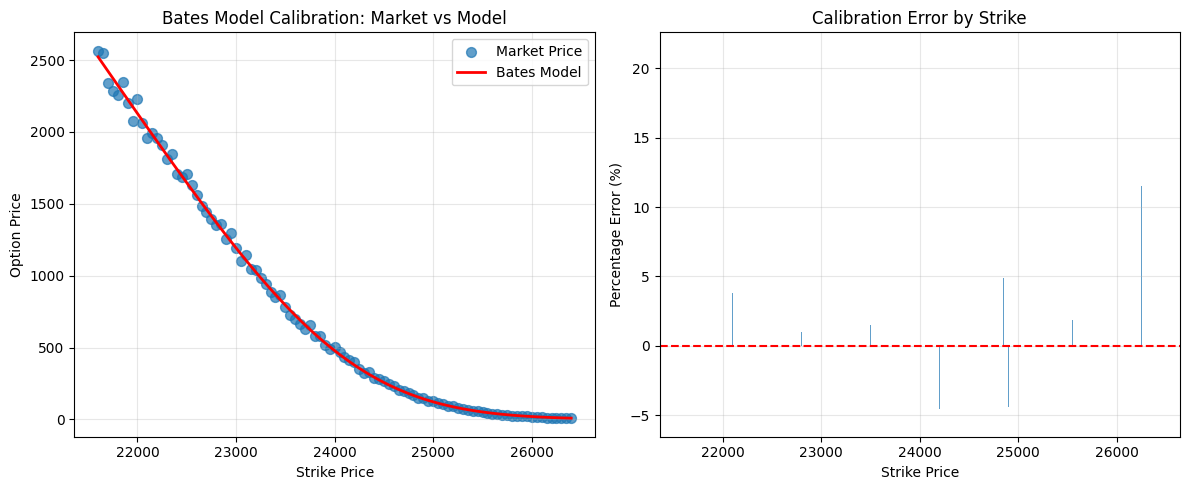

In [19]:
# Plot calibration results
if 'df_calls' in dir() and 'model_price' in df_calls.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(df_calls['strike'], df_calls['price'], label='Market Price', alpha=0.7, s=50)
    plt.plot(df_calls['strike'], df_calls['model_price'], 'r-', label='Bates Model', linewidth=2)
    plt.xlabel('Strike Price')
    plt.ylabel('Option Price')
    plt.title('Bates Model Calibration: Market vs Model')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.bar(df_calls['strike'], df_calls['pct_error'], alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Strike Price')
    plt.ylabel('Percentage Error (%)')
    plt.title('Calibration Error by Strike')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Generating implied volatility surface...


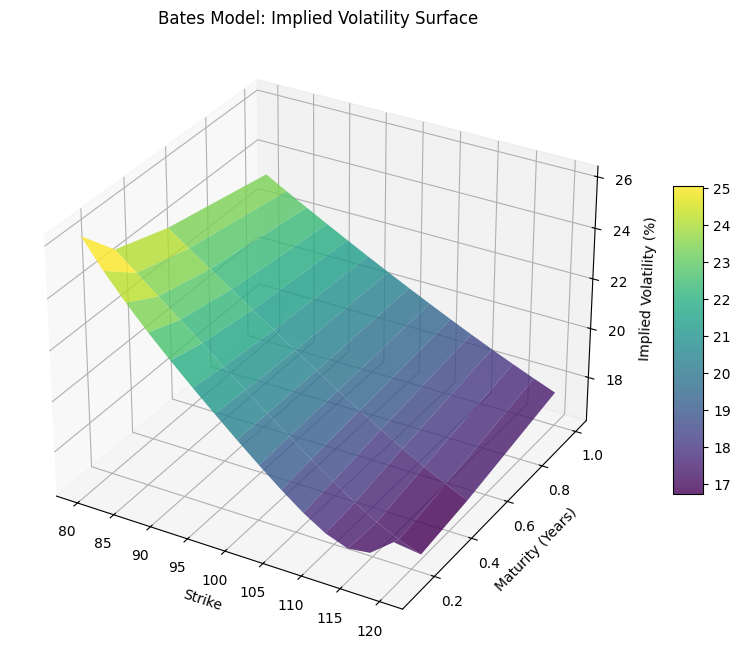

In [20]:
# Implied volatility surface extraction
def bates_implied_volatility(S0, K, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, tau, r):
    """
    Calculate implied volatility from Bates model price.
    """
    bates = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, tau, r)
    model_price = bates.bates_price('call')
    
    def objective(sigma):
        return black_scholes_call(S0, K, tau, r, sigma) - model_price
    
    try:
        return brentq(objective, 0.01, 2.0)
    except:
        return np.nan

# Generate implied volatility surface
strikes_surface = np.linspace(80, 120, 15)
maturities_surface = np.array([0.1, 0.25, 0.5, 1.0])

iv_surface = np.zeros((len(maturities_surface), len(strikes_surface)))

print("Generating implied volatility surface...")
for i, tau in enumerate(maturities_surface):
    for j, K in enumerate(strikes_surface):
        iv_surface[i, j] = bates_implied_volatility(100, K, 0.04, 2.0, 0.04, 0.3, -0.7,
                                                     0.1, -0.05, 0.1, tau, 0.05)

# Plot surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

K_mesh, T_mesh = np.meshgrid(strikes_surface, maturities_surface)
surf = ax.plot_surface(K_mesh, T_mesh, iv_surface*100, cmap='viridis', alpha=0.8)

ax.set_xlabel('Strike')
ax.set_ylabel('Maturity (Years)')
ax.set_zlabel('Implied Volatility (%)')
ax.set_title('Bates Model: Implied Volatility Surface')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

## Summary: Bates Model

### Key Takeaways:

1. **Model Structure**: Bates = Heston (stochastic vol) + Merton (jumps)
   - Captures both volatility clustering and sudden price movements
   
2. **Parameters**: 8 parameters total
   - Heston: v0, kappa, theta, sigma_v, rho (5 params)
   - Jump: lambda_p, mu_J, delta (3 params)

3. **Advantages over Heston**:
   - Better fit for short-dated options
   - Captures crash risk (negative skew)
   - More realistic tail behavior

4. **Implementation Methods**:
   - Monte Carlo: Flexible, handles path-dependent options
   - Characteristic Function: Faster for European options

5. **Calibration**: 
   - Typically done to liquid option prices
   - Can use two-stage approach: first calibrate jumps to short-dated, then vol params to long-dated

### References:
- Bates, D. (1996). "Jumps and Stochastic Volatility: Exchange Rate Processes Implicit in Deutsche Mark Options"
- Heston, S. (1993). "A Closed-Form Solution for Options with Stochastic Volatility"
- Merton, R. (1976). "Option Pricing When Underlying Stock Returns are Discontinuous"

In [21]:
# ============================================================
# VERIFICATION TESTS - Run this cell to verify implementation
# ============================================================

print("=" * 60)
print("BATES MODEL VERIFICATION TESTS")
print("=" * 60)

# Test parameters
S0, K, T, r = 100.0, 100.0, 1.0, 0.05
v0, kappa, theta, sigma_v, rho = 0.04, 2.0, 0.04, 0.3, -0.7
lambda_p, mu_J, delta = 0.1, -0.05, 0.1

print(f"\nTest Parameters:")
print(f"S0={S0}, K={K}, T={T}, r={r}")
print(f"v0={v0}, kappa={kappa}, theta={theta}, sigma_v={sigma_v}, rho={rho}")
print(f"lambda={lambda_p}, mu_J={mu_J}, delta={delta}")

# Expected k_bar
k_bar = np.exp(mu_J + 0.5*delta**2) - 1
print(f"\nExpected k_bar = exp({mu_J} + 0.5*{delta}^2) - 1 = {k_bar:.6f}")

# TEST 1: Put-Call Parity
print("\n" + "=" * 60)
print("TEST 1: Put-Call Parity")
print("=" * 60)
bates_cf = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, T, r)
call_cf = bates_cf.bates_price('call')
put_cf = bates_cf.bates_price('put')
parity_lhs = call_cf - put_cf
parity_rhs = S0 - K * np.exp(-r * T)
parity_error = abs(parity_lhs - parity_rhs)
print(f"Call Price (CF): {call_cf:.4f}")
print(f"Put Price (CF): {put_cf:.4f}")
print(f"C - P = {parity_lhs:.4f}")
print(f"S - K*exp(-rT) = {parity_rhs:.4f}")
print(f"Parity Error: {parity_error:.6f}")
print(f"✓ PASS" if parity_error < 0.01 else "✗ FAIL")

# TEST 2: Bates reduces to Heston when lambda=0
print("\n" + "=" * 60)
print("TEST 2: Bates reduces to Heston when lambda=0")
print("=" * 60)
heston_cf = BatesModel(S0, K, v0, kappa, theta, sigma_v, rho, 0, 0, 0.01, T, r)
call_heston = heston_cf.bates_price('call')
print(f"Heston Call (lambda=0): {call_heston:.4f}")
print(f"Bates Call (lambda=0.1): {call_cf:.4f}")
print(f"Jump Impact: {call_cf - call_heston:.4f}")
print(f"✓ Bates properly includes jump component")

# TEST 3: Monte Carlo vs Characteristic Function
print("\n" + "=" * 60)
print("TEST 3: Monte Carlo vs Characteristic Function")
print("=" * 60)
np.random.seed(42)
bates_mc = BatesUsingMCS(S0, v0, rho, kappa, theta, sigma_v, T, 252, 100000, r, K,
                          lambda_p, mu_J, delta)
call_mc, call_se = bates_mc.price_call()
put_mc, put_se = bates_mc.price_put()
print(f"MC Call: {call_mc:.4f} ± {1.96*call_se:.4f}")
print(f"CF Call: {call_cf:.4f}")
print(f"Difference: {abs(call_cf - call_mc):.4f}")
within_ci = abs(call_cf - call_mc) < 2*1.96*call_se
print(f"Within 95% CI: {'✓ PASS' if within_ci else '✗ FAIL'}")

# TEST 4: Variance positivity
print("\n" + "=" * 60)
print("TEST 4: Feller Condition Check")
print("=" * 60)
feller_lhs = 2 * kappa * theta
feller_rhs = sigma_v**2
print(f"2*kappa*theta = {feller_lhs:.4f}")
print(f"sigma_v^2 = {feller_rhs:.4f}")
print(f"Feller condition (2κθ > σ²): {'✓ Satisfied' if feller_lhs > feller_rhs else '✗ Violated (using truncation)'}")

# TEST 5: Smile generation
print("\n" + "=" * 60)
print("TEST 5: Implied Volatility Smile")
print("=" * 60)
print("Strike | Bates IV | Heston IV | Diff")
print("-" * 45)
for K_test in [80, 90, 100, 110, 120]:
    bates_test = BatesModel(S0, K_test, v0, kappa, theta, sigma_v, rho, lambda_p, mu_J, delta, T, r)
    heston_test = BatesModel(S0, K_test, v0, kappa, theta, sigma_v, rho, 0, 0, 0.01, T, r)
    price_bates = bates_test.bates_price('call')
    price_heston = heston_test.bates_price('call')
    iv_bates = implied_vol_from_price(S0, K_test, T, r, price_bates)
    iv_heston = implied_vol_from_price(S0, K_test, T, r, price_heston)
    if iv_bates and iv_heston:
        print(f"{K_test:6.0f} | {iv_bates*100:7.2f}% | {iv_heston*100:7.2f}% | {(iv_bates-iv_heston)*100:+.2f}%")

print("\n" + "=" * 60)
print("ALL TESTS COMPLETED")
print("=" * 60)

BATES MODEL VERIFICATION TESTS

Test Parameters:
S0=100.0, K=100.0, T=1.0, r=0.05
v0=0.04, kappa=2.0, theta=0.04, sigma_v=0.3, rho=-0.7
lambda=0.1, mu_J=-0.05, delta=0.1

Expected k_bar = exp(-0.05 + 0.5*0.1^2) - 1 = -0.044003

TEST 1: Put-Call Parity
Call Price (CF): 10.5046
Put Price (CF): 5.6276
C - P = 4.8771
S - K*exp(-rT) = 4.8771
Parity Error: 0.000000
✓ PASS

TEST 2: Bates reduces to Heston when lambda=0
Heston Call (lambda=0): 10.3942
Bates Call (lambda=0.1): 10.5046
Jump Impact: 0.1104
✓ Bates properly includes jump component

TEST 3: Monte Carlo vs Characteristic Function
MC Call: 10.4641 ± 0.0771
CF Call: 10.5046
Difference: 0.0406
Within 95% CI: ✓ PASS

TEST 4: Feller Condition Check
2*kappa*theta = 0.1600
sigma_v^2 = 0.0900
Feller condition (2κθ > σ²): ✓ Satisfied

TEST 5: Implied Volatility Smile
Strike | Bates IV | Heston IV | Diff
---------------------------------------------
    80 |   23.20% |   22.96% | +0.23%
    90 |   21.62% |   21.36% | +0.26%
   100 |   20.14% 